## STROKE PREDICTION MODEL (Machine Learning)

This project addresses a binary classification model, where the goal is to predict stroke occurence.  
Following exploratory data analysis and feature engineering, three classification models were evaluated: Logistic Regression, Random Forest, and MLP.  
The dataset presents a significant class imbalance, with stroke cases representing a small minority.   
SMOTE was explored as a resampling strategy however it did not yield satisfactory results for logistic regression and random forest and was therefore excluded from their final pipelines. It was retained solely for the MLP model. As per best practice, SMOTE was applied only on the training set to prevent data leakage into the test set.   
For the logistic regression model and Random Forest, class imbalance will be addressed through native techniques such as class_weight='balanced', and model performance will be evaluated using metrics suited to imbalanced data, primarily precision, recall, and F1-score rather than raw accuracy(not relevant here).

## 1.Import Libraries

In [61]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import precision_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, roc_auc_score, 
                              average_precision_score, precision_recall_curve,f1_score)
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.utils.class_weight import compute_sample_weight
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE

In [63]:
df = pd.read_csv("df_preprocessed.csv", sep=";")
df.head()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,gender_Male,ever_married_Yes,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,3,0,0,95,18,0,1,0,0,0,0,1,0,0,0
1,58,1,0,87,39,0,1,1,0,1,0,0,0,1,0
2,8,0,0,110,17,0,0,0,0,1,0,0,0,0,0
3,70,0,0,69,35,0,0,1,0,1,0,0,1,0,0
4,14,0,0,161,19,0,1,0,1,0,0,0,0,0,0


## 2.Model Evaluation

In [66]:
# Split features and target
X = df.drop(columns=['stroke'])
y = df['stroke']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                                      random_state=42, ## reproducibility
                                                      stratify=y)      ## 5% stroke rate is preserved
print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")
print(f"Stroke rate in train: {y_train.mean()*100:.1f}%")
print(f"Stroke rate in test: {y_test.mean()*100:.1f}%")

# 80/20 split → 3948 train, 987 test
# Stratification worked : stroke rate is consistent at 5% in both sets
# We have one target Stroke and 14 features ready for modelling

# Scale numerical features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Train shape: (3948, 14)
Test shape: (987, 14)
Stroke rate in train: 5.0%
Stroke rate in test: 5.1%


#### Model 1 : Logistic Regression

=== Logistic Regression (balanced) ===

              precision    recall  f1-score   support

   No Stroke       0.99      0.75      0.85       937
      Stroke       0.15      0.82      0.25        50

    accuracy                           0.75       987
   macro avg       0.57      0.78      0.55       987
weighted avg       0.94      0.75      0.82       987

ROC-AUC:   0.8435


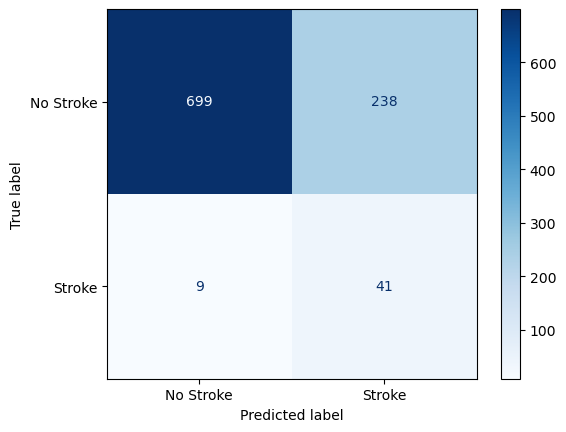

In [68]:
# Logistic Regression

# Add class_weight='balanced'
lr = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced') ## handles imbalance data
lr.fit(X_train, y_train)

# Predictions
y_pred = lr.predict(X_test)
y_prob = lr.predict_proba(X_test)[:, 1] ## extract probability for the positive class stroke

# Evaluation
print("=== Logistic Regression (balanced) ===\n")
print(classification_report(y_test, y_pred, target_names=['No Stroke', 'Stroke']))
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob):.4f}")
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Stroke', 'Stroke'])
disp.plot(cmap='Blues')

Class_weight=balanced was selected to address the significant class imbalance.  
The class_weight = balanced automatically adjusts the model to penalize misclassifications on stroke cases more heavily, proportional to how underrepresented they are in the dataset.  
Results for Logistic Regression:
Stroke recall = 0.82 catches 82% of actual strokes  
The model is over-predicting stroke to compensate for the imbalance (50 vs 937 samples)  

In this model, we would prefer not to miss a stroke (even if we have more false positive)  
Our priority is maximizing recall  
To improve the model, I played on the threshold.  
The threshold determines the cutoff probability for assigning a class label. A threshold set to 0.5, probabilities greater than or equal to 0.5 are classified as positive class, while those below 0.5 are classified as negative class. Adjusting the threshold allows to control the trade-off between false positives and false negatives, especially in the case of imbalanced datasets.  
I also tried to use SMOTE a tool to increase the number of underrepresented stroke cases.   
Both threshold and SMOTE were explored as strategies to improve performance on the stroke class.However none of these approaches produced satisfactory results, and the final pipeline was kept without threshold adjustement or resampling.   

### Model 2 : Random Forest 

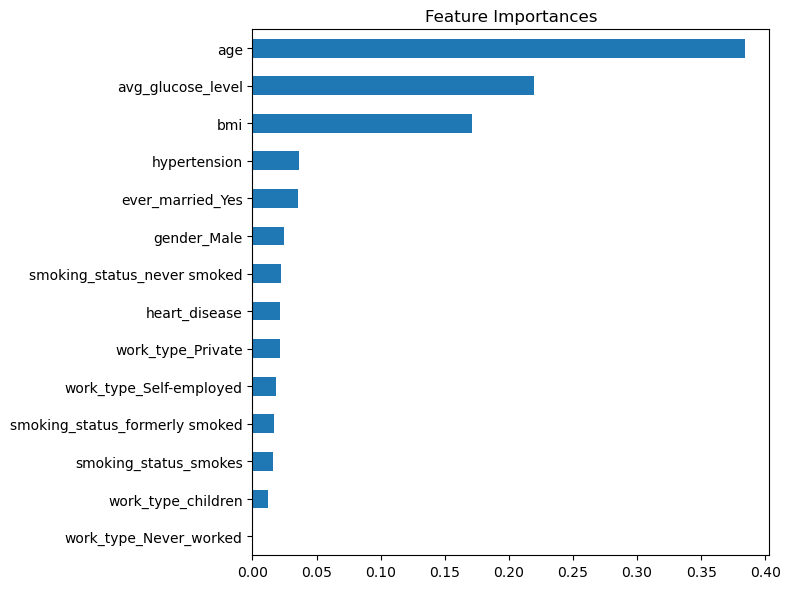

=== Random Forest (default threshold) ===

              precision    recall  f1-score   support

   No Stroke       0.95      1.00      0.97       937
      Stroke       0.00      0.00      0.00        50

    accuracy                           0.95       987
   macro avg       0.47      0.50      0.49       987
weighted avg       0.90      0.95      0.92       987

ROC-AUC: 0.8263


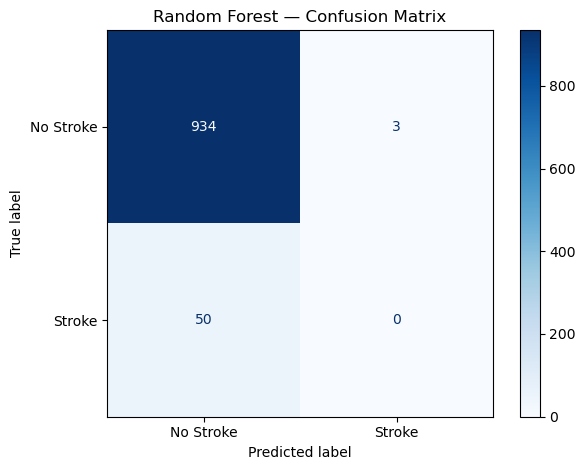

In [72]:
# Train the model
rf = RandomForestClassifier(
    n_estimators=200,        ## nb of trees
    random_state=42,         ## reproducibility
    class_weight='balanced'  ## helps with imbalanced classes
)
rf.fit(X_train, y_train)

# Predictions (default threshold = 0.5)
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1] ## probability for the positive class (stroke)

# feature importance
feature_names = ['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi',
                 'gender_Male', 'ever_married_Yes', 'work_type_Never_worked',
                 'work_type_Private', 'work_type_Self-employed', 'work_type_children',
                 'smoking_status_formerly smoked', 'smoking_status_never smoked',
                 'smoking_status_smokes']

importances = pd.Series(rf.feature_importances_, index=feature_names)
importances.sort_values().plot(kind='barh', figsize=(8,6), title='Feature Importances')
plt.tight_layout()
plt.show()

# Evaluation
print("=== Random Forest (default threshold) ===\n")
print(classification_report(y_test, y_pred, target_names=['No Stroke', 'Stroke']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Stroke', 'Stroke'])
disp.plot(cmap='Blues')
plt.title('Random Forest — Confusion Matrix')
plt.tight_layout()
plt.show()

We need to tune the threshold ,as here we predict no stroke 

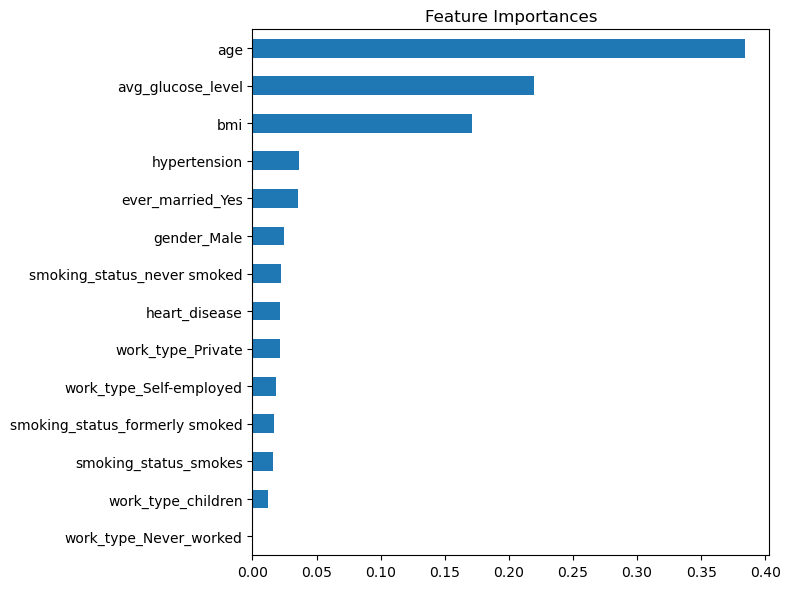

=== Random Forest (threshold = 0.1) ===

              precision    recall  f1-score   support

   No Stroke       0.97      0.85      0.91       937
      Stroke       0.17      0.56      0.26        50

    accuracy                           0.84       987
   macro avg       0.57      0.71      0.58       987
weighted avg       0.93      0.84      0.88       987

ROC-AUC: 0.8263


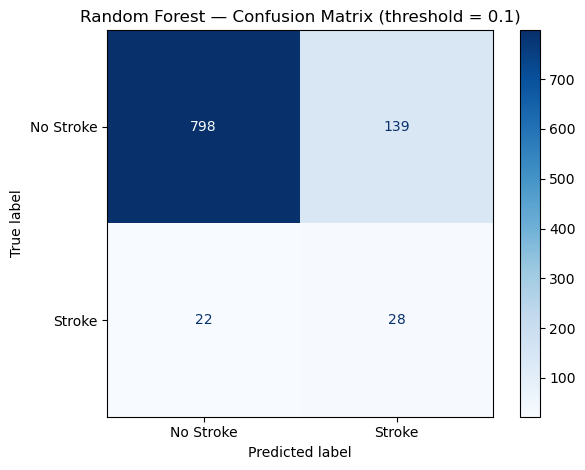

In [76]:
# Train the model
rf = RandomForestClassifier(
    n_estimators=200,      ## number of trees 
    random_state=42,       ## reproducibility
    class_weight='balanced'## penalises mistakes on minority class (stroke)
)
rf.fit(X_train, y_train)

# Get predicted probabilities for the positive class (stroke)
y_prob = rf.predict_proba(X_test)[:, 1]

# Threshold adjustement
# Default threshold is 0.5, too high for imbalanced data, misses all strokes
THRESHOLD = 0.10  ## value is adjusted here to tune precision/recall tradeoff
y_pred = (y_prob >= THRESHOLD).astype(int)


# Feature importance
feature_names = ['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi',
                 'gender_Male', 'ever_married_Yes', 'work_type_Never_worked',
                 'work_type_Private', 'work_type_Self-employed', 'work_type_children',
                 'smoking_status_formerly smoked', 'smoking_status_never smoked',
                 'smoking_status_smokes']

importances = pd.Series(rf.feature_importances_, index=feature_names)
importances.sort_values().plot(kind='barh', figsize=(8,6), title='Feature Importances')
plt.tight_layout()
plt.show()

# Evaluation
print(f"=== Random Forest (threshold = {THRESHOLD}) ===\n")
print(classification_report(y_test, y_pred, target_names=['No Stroke', 'Stroke']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Stroke', 'Stroke'])
disp.plot(cmap='Blues')
plt.title(f'Random Forest — Confusion Matrix (threshold = {THRESHOLD})')
plt.tight_layout()
plt.show()

The Random Forest model struggled significantly with the class imbalance compared to Logistic Regression 
Despite extensive threshold tuning, no threshold produced satisfactory results. 
The best stroke recall achieved remained well below Logistic Regression's 0.82, and precision for the stroke class stayed low, meaning only around 12% of predicted stroke cases were true positives.

This behaviour reflects a fundamental limitation of Random Forest on this dataset: with only 50 stroke cases in training, the model cannot build reliable decision boundaries for the minority class.

The threshold of 0.1 was retained as the most balanced configuration tested. 
This is a precision-recall tradeoff in highly imbalanced medical datasets pushing recall up, inevitably floods the model with false positives

Random Forest does however provide value through its feature importance output.
The most important feature seems to be age, avg_glucose_level and bmi. 
For classification performance on this task, Logistic Regression remains the stronger model.

### 3 Model MPLs

=== MLP (threshold = 0.1) ===

              precision    recall  f1-score   support

   No Stroke       0.91      0.10      0.17       937
      Stroke       0.05      0.82      0.09        50

    accuracy                           0.13       987
   macro avg       0.48      0.46      0.13       987
weighted avg       0.87      0.13      0.17       987

ROC-AUC : 0.4546


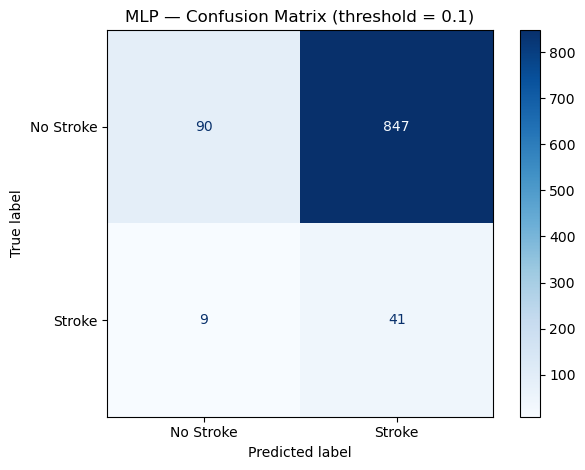

Training stopped at iteration : 22
Final training loss           : 0.1438


In [44]:
# Train
# MLPClassifier has no class_weight parameter
# We rely on threshold adjustment to handle class imbalance
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32), ## two hidden layers: 64 then 32 neurons
    activation='relu',           ## standard activation for tabular data
    solver='adam',               # adam optimizer, efficient and robust
    max_iter=500,                # maximum number of training iterations
    random_state=42,             ## reproducibility
    early_stopping=True,         ## stops training if no improvement
    validation_fraction=0.1,     # 10% of training data used for validation
    n_iter_no_change=20          # stops if no improvement after 20 iterations
)
mlp.fit(X_train, y_train)

# Predict
y_prob_mlp = mlp.predict_proba(X_test)[:, 1]  # probability of stroke

# Threshold
# Default threshold is 0.5, too high for imbalanced data
THRESHOLD = 0.1  # ← adjust this value to tune precision/recall tradeoff
y_pred_mlp = (y_prob_mlp >= THRESHOLD).astype(int)


# Evaluate
print(f"=== MLP (threshold = {THRESHOLD}) ===\n")
print(classification_report(y_test, y_pred_mlp, target_names=['No Stroke', 'Stroke']))
print(f"ROC-AUC : {roc_auc_score(y_test, y_prob_mlp):.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_mlp)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Stroke', 'Stroke'])
disp.plot(cmap='Blues')
plt.title(f'MLP — Confusion Matrix (threshold = {THRESHOLD})')
plt.tight_layout()
plt.show()

# Training info
print(f"Training stopped at iteration : {mlp.n_iter_}")
print(f"Final training loss           : {mlp.loss_:.4f}")

The MLP model with a lowered threshold of 0.1 yields poor overall results, with a ROC-AUC of only 0.45, barely above random chance. 
While the recall for stroke cases reaches 0.82, this comes at the cost of an extremely low precision of 0.05.  
The model generates a very high number of false positives and correctly classifies only 13% of all patients.  
Unlike Logistic Regression, where lowering the threshold represented a meaningful trade-off, the MLP model appears to lack sufficient discriminative power on this dataset.   
The low ROC-AUC confirms that the issue lies in the model itself, not the threshold choice.  
SMOTE will be applied as an additional resampling strategy to address the class imbalance and evaluate whether it can improve the MLP's ability to learn from the minority class.

Before SMOTE: {0: 3749, 1: 199}
After SMOTE:  {0: 3749, 1: 3749}
=== MLP + SMOTE (threshold = 0.1) ===

              precision    recall  f1-score   support

   No Stroke       0.97      0.80      0.88       937
      Stroke       0.12      0.54      0.20        50

    accuracy                           0.79       987
   macro avg       0.55      0.67      0.54       987
weighted avg       0.93      0.79      0.84       987

ROC-AUC : 0.7741


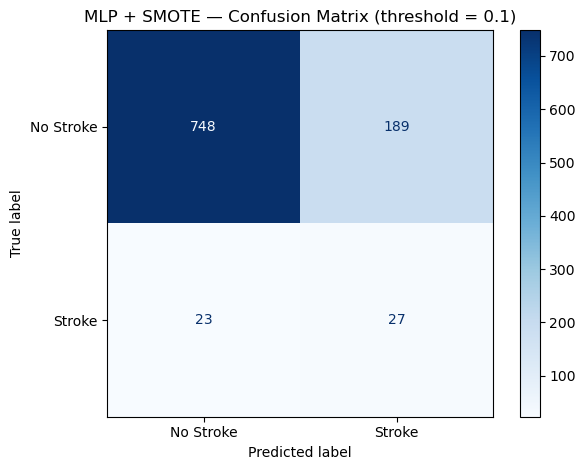

Training stopped at iteration : 137
Final training loss           : 0.1138


In [82]:
# SMOTE resampling (training set only)
# MLPClassifier has no class_weight parameter so we use SMOTE to balance classes
# SMOTE is applied ONLY on training data to avoid data leakage
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE: {dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"After SMOTE:  {dict(zip(*np.unique(y_train_smote, return_counts=True)))}")

# Train on balanced data
mlp.fit(X_train_smote, y_train_smote)

# Predict
y_prob_mlp = mlp.predict_proba(X_test)[:, 1]  # probability of stroke

# Threshold
# Default threshold is 0.5 — too high for imbalanced data
THRESHOLD = 0.1  # ← adjust this value to tune precision/recall tradeoff
y_pred_mlp = (y_prob_mlp >= THRESHOLD).astype(int)


# Evaluate
print(f"=== MLP + SMOTE (threshold = {THRESHOLD}) ===\n")
print(classification_report(y_test, y_pred_mlp, target_names=['No Stroke', 'Stroke']))
print(f"ROC-AUC : {roc_auc_score(y_test, y_prob_mlp):.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_mlp)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Stroke', 'Stroke'])
disp.plot(cmap='Blues')
plt.title(f'MLP + SMOTE — Confusion Matrix (threshold = {THRESHOLD})')
plt.tight_layout()
plt.show()

# Training info
print(f"Training stopped at iteration : {mlp.n_iter_}")
print(f"Final training loss           : {mlp.loss_:.4f}")

In [ ]:
# LR is still the best model
# Both RF and MLP struggle with the extreme imbalance (1:18 ratio)

After applying SMOTE, the training set is perfectly balanced with 3,749 samples per class.  
The MLP model shows a notable improvement compared to the previous run, with a ROC-AUC jumping from 0.45 to 0.77.  
The model now achieves a recall of 0.54 for stroke cases, meaning it correctly identifies 54% of actual stroke patients.  
This is a significant improvement over the previous MLP, though still below the Logistic Regression baseline of 0.82.    
Precision for the stroke class remains low at 0.12  
Overall, SMOTE meaningfully improved the MLP's discriminative ability, confirming that the model was previously struggling due to class imbalance. However, Logistic Regression with class_weight='balanced' remains the strongest performer in terms of stroke recall, which is the priority metric in this medical context.

## General Conclusion

This project applied three classification models to predict stroke occurrence on a highly imbalanced medical dataset, where stroke cases represented only 5% of observations.
Class imbalance was the central challenge throughout.  
Each model required a different strategy to address it.  
Logistic Regression leverage class_weight='balanced'.
Random Forest combined the same parameter with manual threshold tuning.  
MLP required SMOTE resampling on the training set as it offers no native imbalance handling.   
In all cases, accuracy was discarded as a metric in favour of recall, precision, F1-score and ROC-AUC, which better reflect real performance on imbalanced data.
Logistic Regression emerged as the best performing model across all key metrics.
This result is consistent with known behaviour in machine learning, on small, structured, imbalanced medical datasets, simple linear models often outperform more complex architectures.   
With only 50 stroke cases in the training set, Random Forest and MLP lacked sufficient minority class examples to build reliable decision boundaries, regardless of the resampling or threshold strategy applied.
The priority throughout was maximising stroke recall in a medical context, missing a true stroke patient carries greater risk than generating a false alarm. 
Logistic Regression achieved a recall of 0.82, meaning it correctly identified 82% of stroke patients in the test set, making it the most clinically relevant model of the three.
Key limitations of this study include the small number of stroke cases, the absence of temporal or clinical context, and the relatively simple feature set.  
Future work could explore gradient boosting methods such as XGBoost or LightGBM, more aggressive oversampling strategies, or the collection of additional stroke cases to improve minority class representation.

#### Fundamental limitations of this dataset:
1. Extreme class imbalance
Only 5% stroke cases. Even with SMOTE and threshold tuning, the models are working with very little signal.
50 stroke cases in training is simply not enough for complex models to learn reliable patterns.
2. Missing critical clinical features
The dataset lacks several of the strongest known stroke predictors:
- Blood pressure
- Cholesterol levels
- Family history
- Atrial fibrillation (responsible for 20% of strokes)
- Anticoagulants directly affect risk
3. Static snapshot problem
Stroke risk is dynamic, a single measurement of glucose or BMI tells you far less than a trend over time.
This dataset has no temporal dimension.
4. avg_glucose_level without context
Without knowing if a patient is fasting, post-meal, or diabetic and medicated, glucose values are hard to interpret accurately.

#### How to improve:
More data :
- Collect more stroke cases
- Merge with other public stroke datasets like MIMIC-III

Better features
- Add blood pressure, cholesterol, atrial fibrillation
- Include medication and family history
- Add time-series measurements rather than single snapshots

Better evaluation
Use cross-validation instead of a single train/test split with only 50 stroke cases, one split is not statistically robust
Focus on PR-AUC rather than ROC-AUC more informative when positive class is rare

Bottom line:
This dataset does contains meaningful signal : age, glucose,bmi and hypertension do separate stroke from non-stroke patients to a degree.   
However with only 50 stroke cases in the test set and several critical clinical features absent, it is not sufficient for any real clinical application.  
A hospital grade stroke prediction model would require richer longitudinal data, validated clinical features, and far more positive cases.